# Graphs of the Regression Test

The regression suite in [`tests/regression/test_regression.py`](../../tests/regression/test_regression.py) checks that every kernel reproduces frozen kernel matrices. The graphs used by these checks live in `tests/regression/data/graphs.json`.

This notebook presents those graphs: their generator families and parameters, their structural properties, the train/test split used by the tests, and visualizations (adjacency matrices and NetworkX drawings).


## Loading the graphs

The graphs are loaded exactly like the regression test does: each record stores an edge dictionary, node labels and edge labels, plus metadata about the generator that produced it.


In [8]:
import ast
import json
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import grakel
from grakel import Graph

%matplotlib inline


In [9]:
def _repo_root(start=None):
    # Walk up from the current working directory until we find the repo
    # root that contains the regression data, so the notebook works
    # regardless of the directory it is launched from.
    cur = (start or Path.cwd()).resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "tests" / "regression" / "data" / "graphs.json").exists():
            return parent
    raise FileNotFoundError(
        "tests/regression/data/graphs.json not found from "
        f"{Path.cwd()}")


def _parse_edge_key(key):
    value = ast.literal_eval(key)
    if not isinstance(value, tuple) or len(value) != 2:
        raise ValueError(f"invalid edge key: {key!r}")
    return tuple(int(node) for node in value)


def _load_registry():
    data_dir = _repo_root() / "tests" / "regression" / "data"
    registry = json.loads((data_dir / "graphs.json").read_text())
    specs = json.loads((data_dir / "specifications.json").read_text())
    graphs, meta = {}, {}
    for record in registry["graphs"]:
        edge_dictionary = {
            int(node): [int(neighbor) for neighbor in neighbors]
            for node, neighbors in record["edge_dictionary"].items()
        }
        node_labels = {
            int(node): label for node, label in record["node_labels"].items()
        }
        edge_labels = {
            _parse_edge_key(edge): label
            for edge, label in record["edge_labels"].items()
        }
        graphs[record["name"]] = Graph(
            edge_dictionary,
            node_labels=node_labels,
            edge_labels=edge_labels,
            graph_format="dictionary",
        )
        meta[record["name"]] = record
    return graphs, meta, specs


graphs, meta, specs = _load_registry()
print(f"Loaded {len(graphs)} graphs:")
for name in graphs:
    print(f"  - {name}")


Loaded 18 graphs:
  - er_sparse_10
  - er_sparse_20
  - er_dense_10
  - er_dense_20
  - ws_10
  - ws_20
  - ba_20
  - ba_50
  - rr_10
  - rr_20
  - path_10
  - path_20
  - cycle_10
  - cycle_20
  - star_10
  - star_20
  - complete_10
  - complete_20


## Overview of the graph families

The dataset covers 8 generator families, from sparse random graphs to fully connected ones. Structured generators (`path`, `cycle`, `star`, `complete`) are deterministic and have no seed; random families (`erdos_renyi`, `watts_strogatz`, `barabasi_albert`, `random_regular`) are seeded for reproducibility.


In [10]:
rows = []
for name, g in meta.items():
    gen = g["generator"]
    rows.append({
        "graph": name,
        "family": g["topology"],
        "generator": gen["name"],
        "params": gen["params"],
        "seed": gen["seed"],
        "n": g["n"],
        "m": sum(len(nb) for nb in g["edge_dictionary"].values()) // 2,
        "node_labels": len(set(g["node_labels"].values())),
        "edge_labels": len(set(g["edge_labels"].values())) if g["edge_labels"] else 0,
    })
df_meta = pd.DataFrame(rows)
df_meta


,graph,family,generator,params,seed,n,m,node_labels,edge_labels
0,er_sparse_10,erdos_renyi,erdos_renyi,{'p': 0.15},101.0,10,7,4,4
1,er_sparse_20,erdos_renyi,erdos_renyi,{'p': 0.1},102.0,20,14,5,5
2,er_dense_10,erdos_renyi,erdos_renyi,{'p': 0.7},103.0,10,30,3,4
3,er_dense_20,erdos_renyi,erdos_renyi,{'p': 0.6},104.0,20,120,8,13
4,ws_10,watts_strogatz,watts_strogatz,"{'k': 4, 'p': 0.2}",105.0,10,20,5,6
5,ws_20,watts_strogatz,watts_strogatz,"{'k': 4, 'p': 0.2}",106.0,20,40,5,7
6,ba_20,barabasi_albert,barabasi_albert,{'m': 2},107.0,20,36,6,11
7,ba_50,barabasi_albert,barabasi_albert,{'m': 2},108.0,50,96,10,20
8,rr_10,random_regular,random_regular,{'d': 3},109.0,10,15,1,1
9,rr_20,random_regular,random_regular,{'d': 4},110.0,20,40,1,1


## Structural properties

Beyond the metadata, we compute the properties that reveal each graph's shape: density, degree statistics, number of connected components and diameter (only defined for connected graphs). Notice how `er_sparse_10` and `er_sparse_20` are disconnected, while the seeded regular/structured families are connected.


In [11]:
def _to_nx_dict(g):
    return {int(k): [int(x) for x in v] for k, v in g["edge_dictionary"].items()}


def _diameter(ed):
    nxg = nx.from_dict_of_lists(ed)
    comps = list(nx.connected_components(nxg))
    if len(comps) > 1:
        return float("inf"), len(comps)
    return nx.diameter(nxg), 1


props = []
for name, g in meta.items():
    ed = _to_nx_dict(g)
    n = g["n"]
    m = sum(len(nb) for nb in ed.values()) // 2
    nxg = nx.from_dict_of_lists(ed)
    degs = [d for _, d in nxg.degree()]
    diameter, components = _diameter(ed)
    props.append({
        "graph": name,
        "density": round(2 * m / (n * (n - 1)), 3),
        "avg_degree": round(np.mean(degs), 2),
        "max_degree": max(degs),
        "components": components,
        "diameter": "inf" if diameter == float("inf") else diameter,
    })
df_props = pd.DataFrame(props)
df_props


,graph,density,avg_degree,max_degree,components,diameter
0,er_sparse_10,0.156,1.40,3,4,inf
1,er_sparse_20,0.074,1.40,4,7,inf
2,er_dense_10,0.667,6.00,7,1,2
3,er_dense_20,0.632,12.00,15,1,2
4,ws_10,0.444,4.00,6,1,3
5,ws_20,0.211,4.00,7,1,4
6,ba_20,0.189,3.60,10,1,3
7,ba_50,0.078,3.84,16,1,5
8,rr_10,0.333,3.00,3,1,3
9,rr_20,0.211,4.00,4,1,3


## Train/test split

The regression test splits the graphs into a training set (fit/fit_transform) and a test set (transform). An important subtlety: test graphs carry node/edge labels that never appear in the training set, which is exactly what kernels are exercised against.


In [12]:
split = specs["split"]
df_split = pd.DataFrame({
    "train": pd.Series(split["train"], dtype="object"),
    "test": pd.Series(split["test"], dtype="object"),
})
df_split


,train,test
0,er_sparse_10,er_dense_20
1,er_dense_10,ba_50
2,ws_10,path_20
3,ba_20,cycle_20
4,rr_10,star_20
5,path_10,complete_20
6,cycle_10,NaN
7,star_10,NaN
8,complete_10,NaN
9,er_sparse_20,NaN


In [13]:
train_labels = {l for name in split["train"] for l in meta[name]["node_labels"].values()}
test_labels = {l for name in split["test"] for l in meta[name]["node_labels"].values()}
print(f"Node labels: {len(train_labels)} in train, {len(test_labels)} in test, "
      f"{len(test_labels - train_labels)} only in test: {sorted(test_labels - train_labels)}")


Node labels: 10 in train, 17 in test, 8 only in test: ['11', '12', '13', '14', '15', '16', '19', '8']


## Adjacency matrices

An adjacency matrix gives the best at-a-glance view of all 18 graphs: sparse random graphs show a few scattered entries, dense and complete graphs fill the matrix, and structured families (path, cycle, star) draw recognizable patterns.


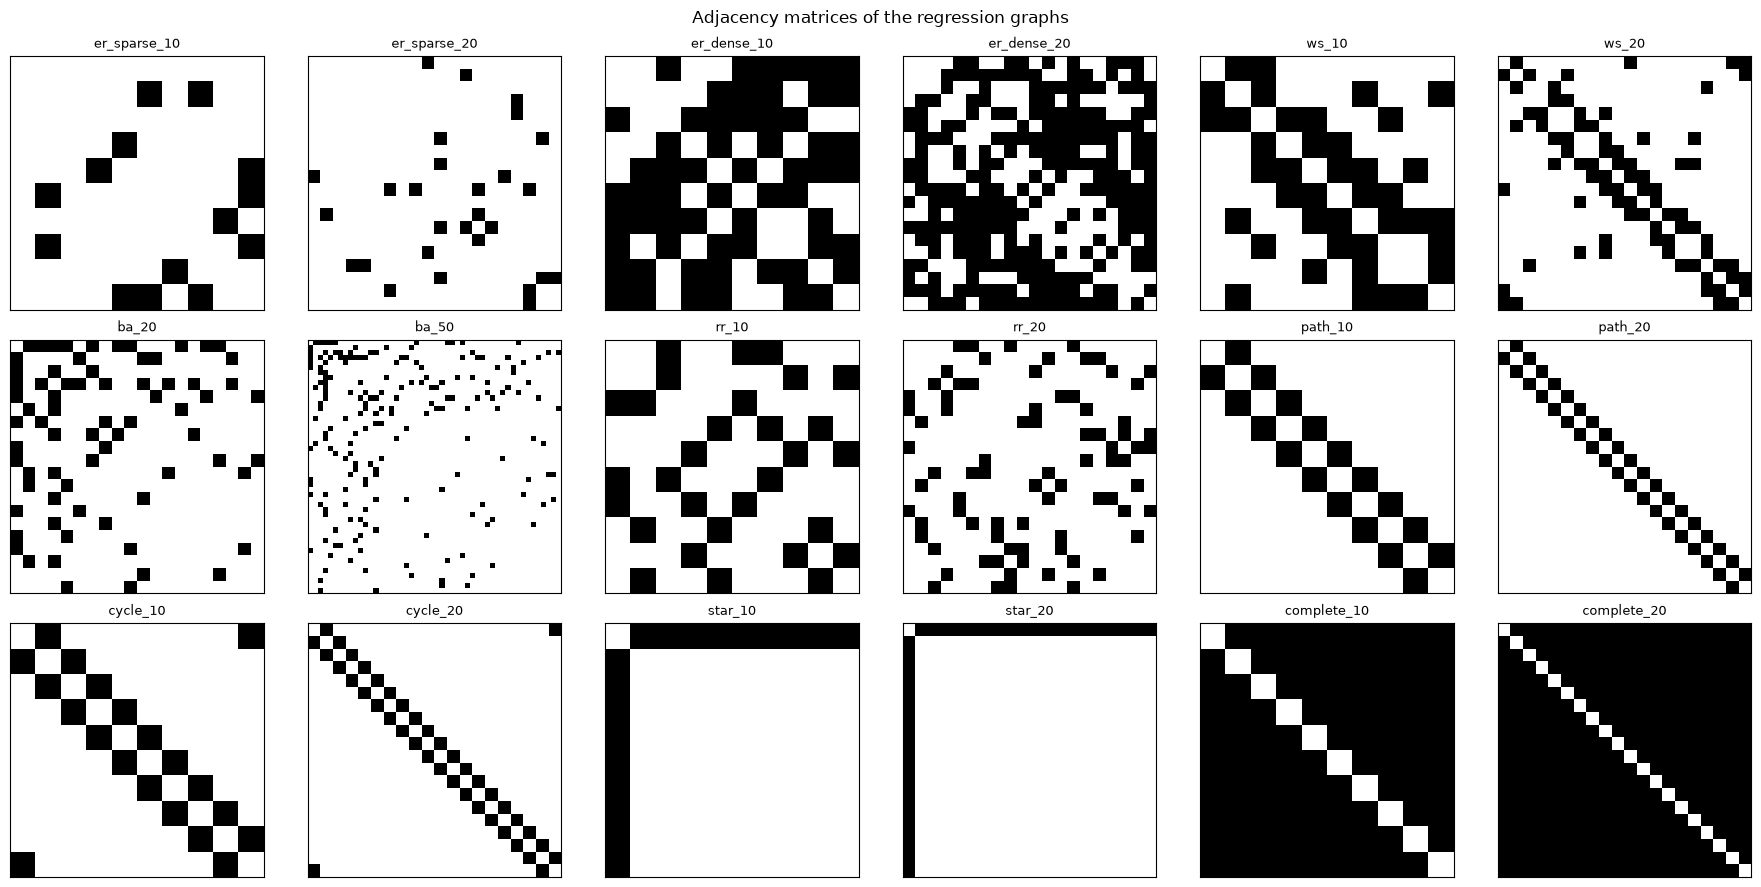

In [14]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for ax, name in zip(axes.ravel(), meta):
    g = meta[name]
    n = g["n"]
    A = np.zeros((n, n))
    for u, nbs in _to_nx_dict(g).items():
        for v in nbs:
            A[u, v] = 1
    ax.imshow(A, cmap="Greys", interpolation="none")
    ax.set_title(name, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Adjacency matrices of the regression graphs")
plt.tight_layout()


## NetworkX drawings

We convert each graph to a `networkx.Graph` (the edge dictionary is symmetric, so an undirected graph drops the duplicates) and color the nodes by their label. The smaller graphs are drawn in full; the large ones (`er_dense_20`, `ba_50`, `complete_20`) are drawn individually to stay readable.


In [21]:
def to_networkx(name):
    g = meta[name]
    nxg = nx.from_dict_of_lists(_to_nx_dict(g))
    nx.set_node_attributes(nxg, {int(k): v for k, v in g["node_labels"].items()}, name="label")
    el = {ast.literal_eval(k): v for k, v in g["edge_labels"].items()}
    el = {e: lbl for e, lbl in el.items() if e[0] < e[1]}
    if el:
        nx.set_edge_attributes(nxg, el, name="label")
    return nxg


def draw(nxg, ax, title):
    labels = sorted({d["label"] for _, d in nxg.nodes(data=True)})
    cmap = plt.cm.tab10
    colors = {l: cmap(i % 10) for i, l in enumerate(labels)}
    node_colors = [colors[nxg.nodes[u]["label"]] for u in nxg]
    pos = nx.spring_layout(nxg, seed=0)
    nx.draw_networkx(nxg, pos, ax=ax, node_color=node_colors, with_labels=True,
                     node_size=200, font_size=7, edge_color="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")


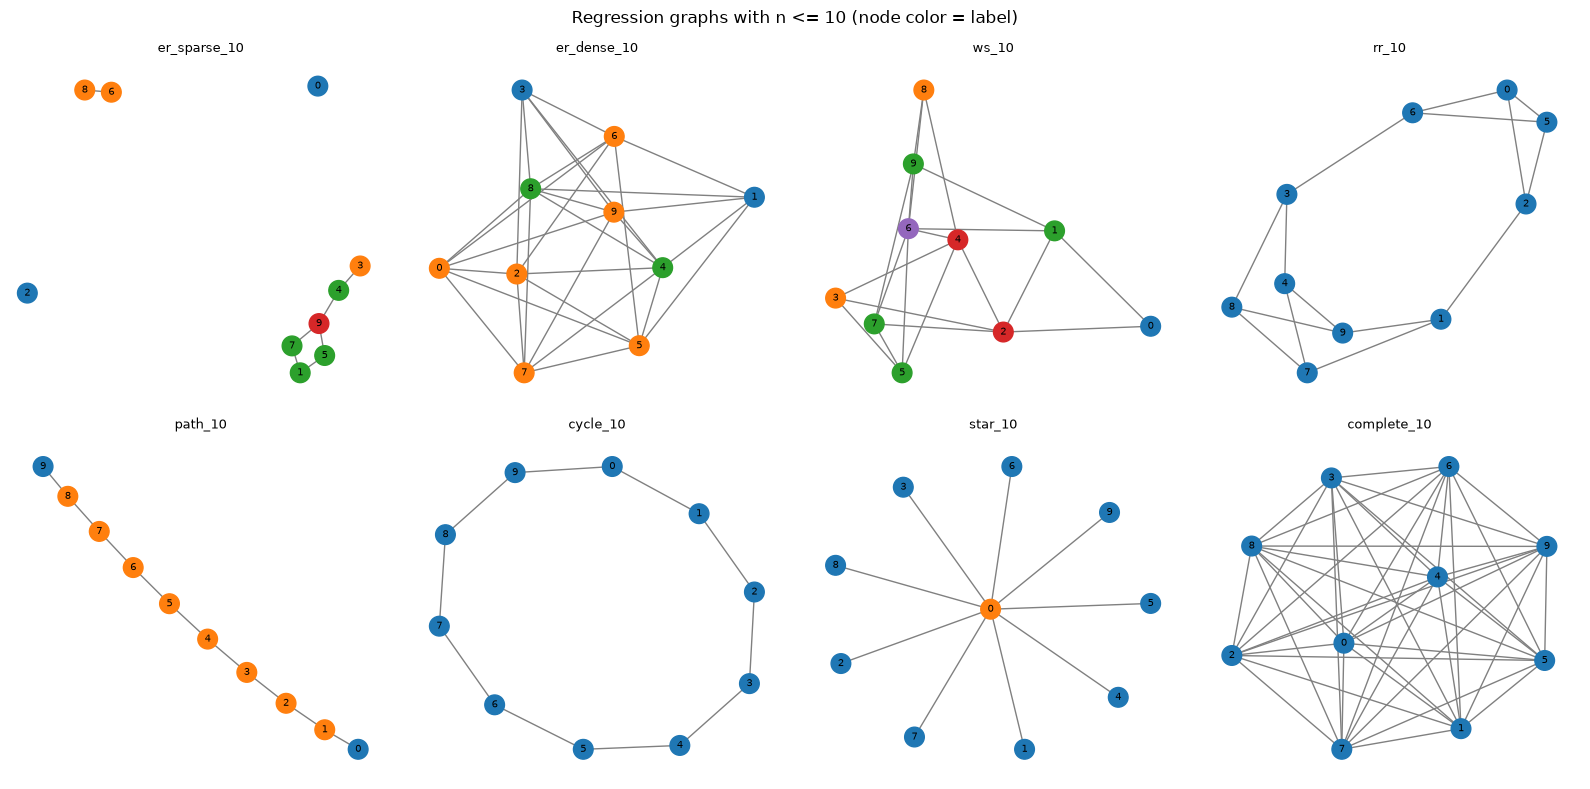

In [22]:
small = [n for n in meta if meta[n]["n"] <= 10]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, name in zip(axes.ravel(), small):
    draw(to_networkx(name), ax, name)
fig.suptitle("Regression graphs with n <= 10 (node color = label)")
plt.tight_layout()


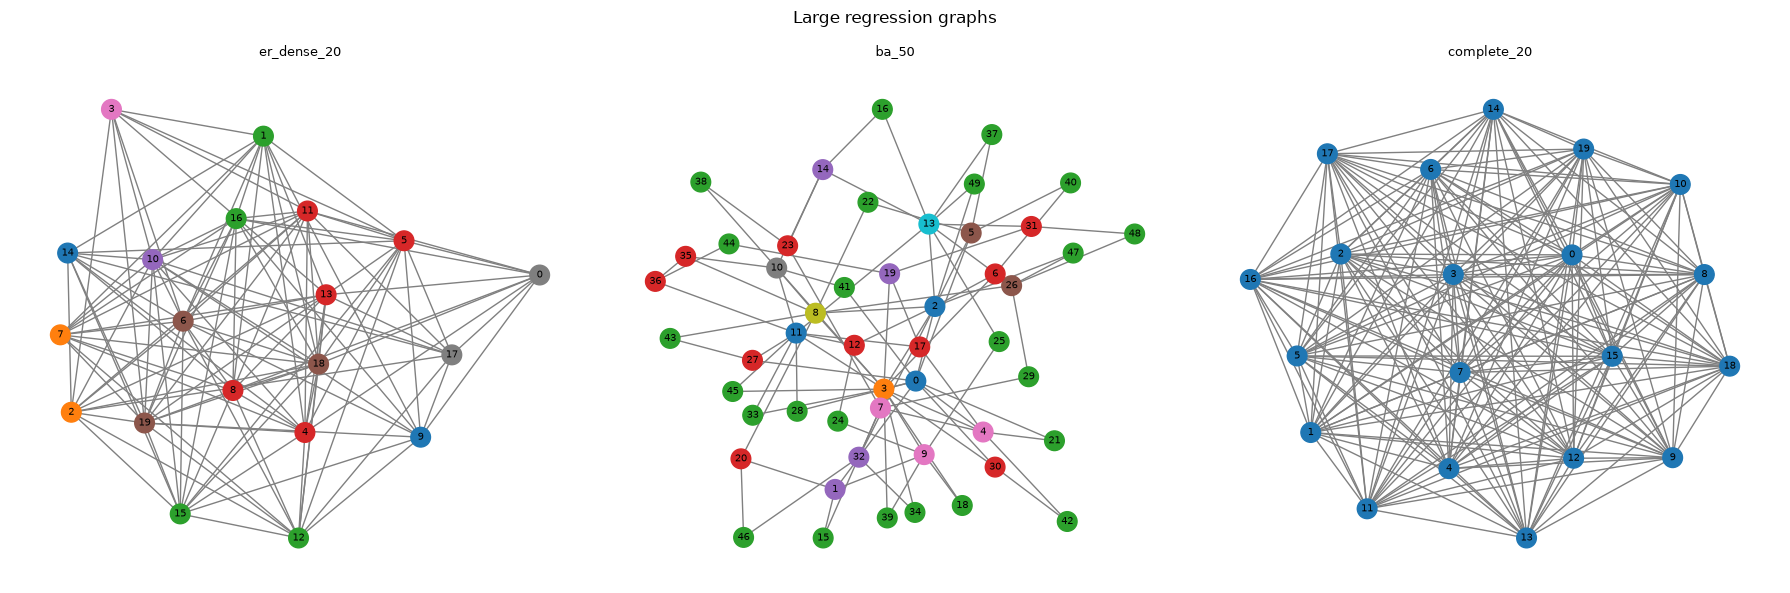

In [23]:
large = ["er_dense_20", "ba_50", "complete_20"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name in zip(axes, large):
    draw(to_networkx(name), ax, name)
fig.suptitle("Large regression graphs")
plt.tight_layout()


## Summary

The regression dataset is deliberately diverse: 8 generator families, sizes from 10 to 50 nodes, sparse to fully connected topologies, and node/edge labels with values held out of the training split. This variety is what makes the frozen-matrix checks meaningful across all kernels.
